# k-means clustering of iris petal data

BS.49903 · DS/AI for Biology

We cluster 150 iris flowers into 3 groups using only two measurements:
petal length and petal width.

## 1. Load the data — and look at it first

Before clustering anything, check what columns you actually have.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("iris_data.csv")
df.head()

,sample,petal_length_cm,petal_width_cm,species
0,1,1.4,0.2,setosa
1,2,1.4,0.2,setosa
2,3,1.3,0.2,setosa
3,4,1.5,0.2,setosa
4,5,1.4,0.2,setosa


In [2]:
df.shape, list(df.columns)

((150, 4), ['sample', 'petal_length_cm', 'petal_width_cm', 'species'])

In [3]:
df.dtypes

sample               int64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

Note what's in here. Four columns, three of them numeric:

- `sample` — a row index, 1 to 150. Not a measurement.
- `petal_length_cm`, `petal_width_cm` — the actual measurements.
- `species` — the true label. k-means never sees this.

Only two of these are features. `sample` is numeric, so every "just use the
numeric columns" shortcut will happily pick it up — and it is a trap.

In [4]:
df.describe()

,sample,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000
mean,75.500000,3.758000,1.199333
std,43.445368,1.765298,0.762238
min,1.000000,1.000000,0.100000
25%,38.250000,1.600000,0.300000
50%,75.500000,4.350000,1.300000
75%,112.750000,5.100000,1.800000
max,150.000000,6.900000,2.500000


## 2. Choose the features deliberately

Select the two measurement columns by name. Do not reach for
`select_dtypes('number')` or `df.iloc[:, 1:]` — see section 6 for why.

In [5]:
X = df[["petal_length_cm", "petal_width_cm"]].values
X.shape

(150, 2)

## 3. Look at the data before clustering

How many groups do you see?

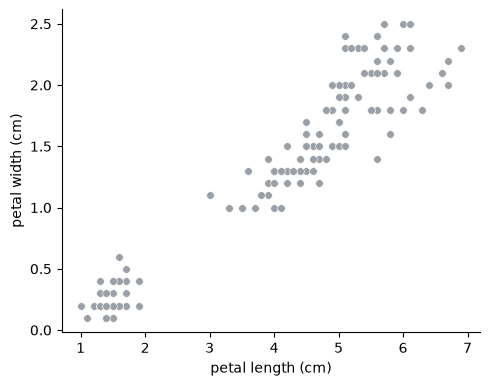

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(X[:, 0], X[:, 1], c="#9AA0A6", s=30, edgecolors="white", linewidths=0.4)
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Most people say two — the gap on the lower left is the only obvious break.
We are about to ask for three.

## 4. Fit k-means

`random_state=0` fixes the initialisation so cluster numbering is reproducible.
Without it the labels permute between runs.

In [7]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
labels = km.labels_

print("cluster sizes:", pd.Series(labels).value_counts().sort_index().to_dict())
print("inertia: %.2f" % km.inertia_)

pd.DataFrame(km.cluster_centers_,
             columns=["petal_length_cm", "petal_width_cm"],
             index=[f"cluster {i}" for i in range(3)]).round(2)

cluster sizes: {0: 52, 1: 50, 2: 48}
inertia: 31.37


,petal_length_cm,petal_width_cm
cluster 0,4.27,1.34
cluster 1,1.46,0.25
cluster 2,5.60,2.04


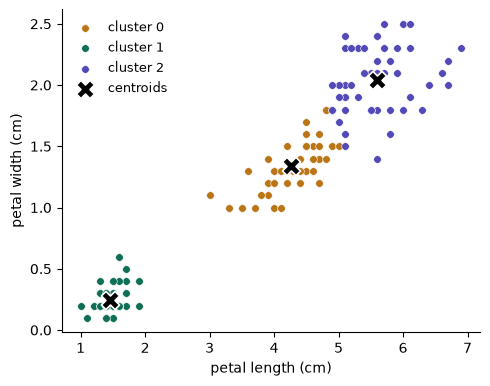

In [8]:
COLORS = ["#BA7517", "#0F6E56", "#534AB7"]

fig, ax = plt.subplots(figsize=(5.4, 4.2))
for k in range(3):
    m = labels == k
    ax.scatter(X[m, 0], X[m, 1], c=COLORS[k], s=30, label=f"cluster {k}",
               edgecolors="white", linewidths=0.4)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           marker="X", s=170, c="black", edgecolors="white", linewidths=1.2,
           label="centroids", zorder=5)
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 5. Check the result against the species labels

k-means never saw `species`. This is the first honest test of whether the
clusters mean anything biological.

In [9]:
pd.crosstab(df["species"], labels)

col_0,0,1,2
species,,,
setosa,0,50,0
versicolor,48,0,2
virginica,4,0,46


Setosa is recovered perfectly: 50 out of 50. Versicolor and virginica are not —
six flowers land on the wrong side of the boundary.

Those six are invisible in the scatter plot and invisible in the code. You only
find them by putting the cluster column next to the species column.

In [10]:
df["kmeans_cluster"] = labels
mismatch = df[
    ((df["species"] == "versicolor") & (df["kmeans_cluster"] == 2)) |
    ((df["species"] == "virginica") & (df["kmeans_cluster"] == 0))
]
mismatch[["sample", "petal_length_cm", "petal_width_cm", "species", "kmeans_cluster"]]

,sample,petal_length_cm,petal_width_cm,species,kmeans_cluster
77,78,5.0,1.7,versicolor,2
83,84,5.1,1.6,versicolor,2
106,107,4.5,1.7,virginica,0
119,120,5.0,1.5,virginica,0
126,127,4.8,1.8,virginica,0
138,139,4.8,1.8,virginica,0


## 6. What happens if you don't inspect the columns

Now the part worth remembering. Feed in every numeric column and k-means still
returns three tidy clusters — no error, no warning.

Check the crosstab against species carefully before reading on.

In [11]:
X_naive = df.select_dtypes("number").drop(columns=["kmeans_cluster"]).values
print("columns used:", list(df.select_dtypes("number").drop(columns=["kmeans_cluster"]).columns))

naive = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X_naive)
print("cluster sizes:", pd.Series(naive).value_counts().sort_index().to_dict())
pd.crosstab(df["species"], naive)

columns used: ['sample', 'petal_length_cm', 'petal_width_cm']
cluster sizes: {0: 50, 1: 50, 2: 50}


col_0,0,1,2
species,,,
setosa,50,0,0
versicolor,0,50,0
virginica,0,0,50


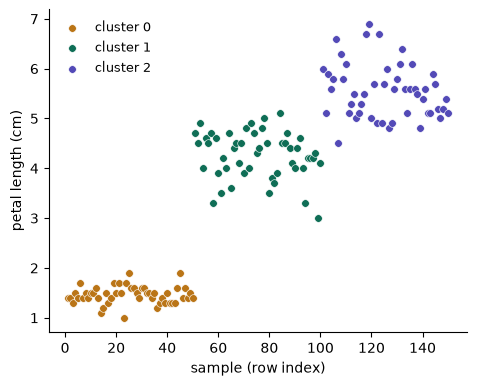

In [12]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
for k in range(3):
    m = naive == k
    ax.scatter(df["sample"][m], df["petal_length_cm"][m], c=COLORS[k], s=30,
               label=f"cluster {k}", edgecolors="white", linewidths=0.4)
ax.set_xlabel("sample (row index)")
ax.set_ylabel("petal length (cm)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**150 out of 150.** Three clusters of exactly 50, perfectly aligned with the
three species. A flawless result.

It is entirely meaningless.

`sample` runs from 1 to 150 while the petal measurements span 0.1 to 6.9, so the
row index dominates the distance calculation and swamps the biology. The three
clusters are rows 1–50, 51–100, and 101–150. The file happens to be sorted by
species, so partitioning the spreadsheet by row number reproduces the species
labels exactly.

The measurements contributed almost nothing. The plot above shows it: the split
is vertical, along the row index, not along petal length.

Now compare the scores. The careful analysis in section 4 got 144 out of 150.
This one got 150 out of 150. **The wrong analysis scored higher**, and every
number you would normally check — cluster sizes, crosstab, accuracy — looks
better for it.

No error was raised. No warning appeared. The only thing that separates the two
is whether you looked at your columns first.

## Exercise

1. Re-run section 4 without `random_state`. What changes, and what doesn't?
2. Try k = 2, 4, 5. Which value would you defend, and on what grounds?
3. Standardise the two features before clustering. Does the result move? Why?
4. Implement `KMeans` yourself and reproduce the section 4 result.